In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

### Load dataset

In [3]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box
import torch

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = class_concept_matrix.shape[1]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

AllenNLP not available. Registrable won't work.


Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [4]:
from src.CHM.model import ConceptBottleneckClassifier, ConceptPredictor
from src.CHM.train import sequential_training
import matplotlib.pyplot as plt
from src.CHM.test import test_sequential_cbm
from src.utils.plot import plot_history, plot_test_results
import torch.nn as nn

#### Train

In [5]:
concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
concept_optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
concept_criterion = nn.BCEWithLogitsLoss()


In [6]:
from src.CP.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor,
    train_dataloader,
    val_dataloader,
    class_concept_matrix,
    concept_optimizer,
    concept_criterion,
    EPOCHS,
    device
)

Loss: 3.5792 | Acc: 95.9246 || Val Loss: 2.5896 | Val Acc: 96.9901
Loss: 2.2586 | Acc: 97.4188 || Val Loss: 2.3100 | Val Acc: 97.2917
Loss: 1.9587 | Acc: 97.7487 || Val Loss: 2.2092 | Val Acc: 97.4176
Loss: 1.7878 | Acc: 97.9368 || Val Loss: 2.1833 | Val Acc: 97.4573
Loss: 1.6601 | Acc: 98.0834 || Val Loss: 2.1032 | Val Acc: 97.5660
Loss: 1.5658 | Acc: 98.1902 || Val Loss: 2.1320 | Val Acc: 97.5366
Loss: 1.4971 | Acc: 98.2774 || Val Loss: 2.0885 | Val Acc: 97.5628
Loss: 1.4289 | Acc: 98.3498 || Val Loss: 2.1590 | Val Acc: 97.5484
Loss: 1.3848 | Acc: 98.4007 || Val Loss: 2.1806 | Val Acc: 97.4969
Loss: 1.3399 | Acc: 98.4498 || Val Loss: 2.1938 | Val Acc: 97.5344
Loss: 1.2976 | Acc: 98.4928 || Val Loss: 2.1872 | Val Acc: 97.5542
Loss: 1.2714 | Acc: 98.5283 || Val Loss: 2.2268 | Val Acc: 97.4905
Loss: 1.2376 | Acc: 98.5736 || Val Loss: 2.2288 | Val Acc: 97.5108
Loss: 1.2088 | Acc: 98.6102 || Val Loss: 2.2135 | Val Acc: 97.5264
Loss: 1.1860 | Acc: 98.6216 || Val Loss: 2.2704 | Val Acc: 97.

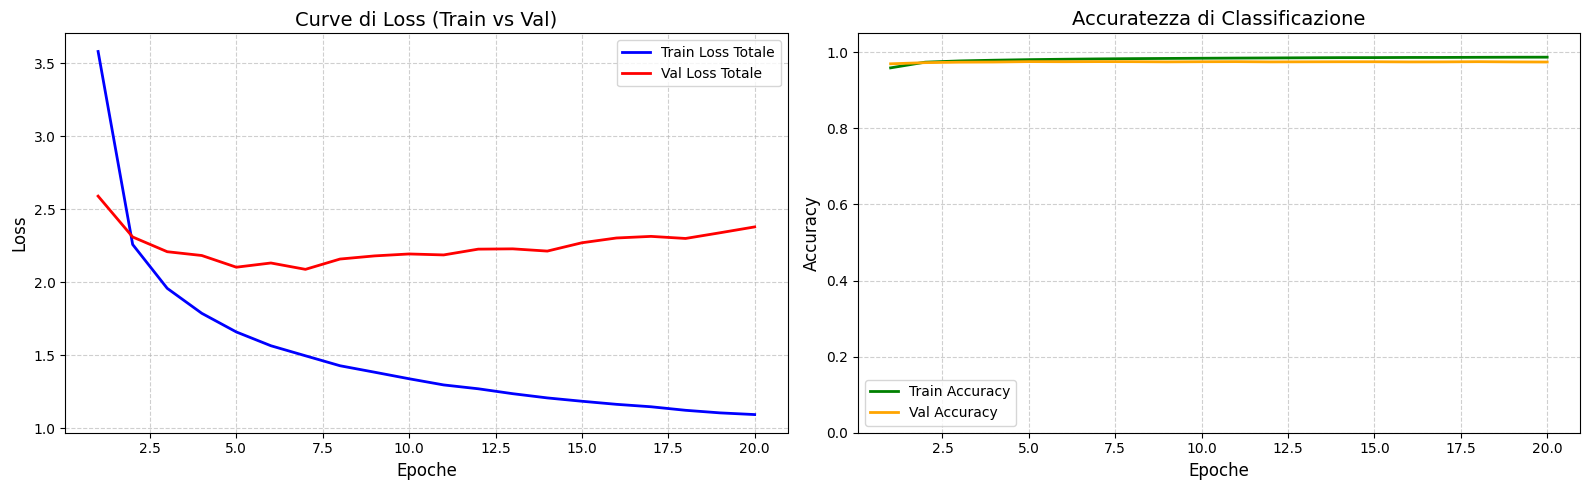

In [7]:
from src.utils.plot import plot_history
plot_history(history)

#### Test

In [8]:
from src.CP.test import test_concept_predictor

(
    avg_loss, 
    avg_acc, 
    all_preds_probs, 
    all_preds_binary, 
    all_gts
) = test_concept_predictor(
    concept_predictor,
    test_dataloader,
    class_concept_matrix,
    concept_criterion,
    device
)

Inizio valutazione del Concept Predictor sul Test Set...
--------------------------------------------------
TEST CONCEPT PREDICTOR COMPLETATO
Test Loss: 0.0748
Test Concept Accuracy (Globale): 97.47%
--------------------------------------------------
